In [1]:
# Installation automatique des dependances requises dans le noyau Jupyter actuel.
import subprocess, sys
for pkg in ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn', 'xgboost']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=False)
print('Dependances verifiees.')

Dependances verifiees.


# 🧠 Étape 5 : Modélisation — Prédiction du résultat des matchs internationaux

Cette étape est le cœur du **Jalon 2**. On entraîne deux modèles d'apprentissage supervisé pour prédire l'issue d'un match (`home_win` / `draw` / `away_win`), avec en ligne de mire la **Coupe du Monde FIFA 2026**.

**Donnée d'entrée :** `data/processed/matches_clean.csv` — 30 511 matchs nettoyés (1993 → mars 2026), classements FIFA inclus.

**Approche — alignée sur le chapitre 5 du cours :**

- Tâche : **classification multi-classes** sur données tabulaires (§5.2 du cours).
- Deux modèles, exactement ceux que le cours implémente en Python :
  - **Random Forest** — méthode d'ensemble par *Bagging* (§5.6.1) ;
  - **XGBoost** — méthode d'ensemble par *Boosting* (§5.6.2).
- Concepts clés (§5.7) mobilisés : compromis biais-variance, sur-ajustement, importance d'une baseline.

**Deux apports de cette version :**

1. un *feature engineering* enrichi — on reconstruit l'**historique réel de chaque équipe** (buts marqués/encaissés, forme récente, force des adversaires) ;
2. une **analyse par groupe** — on applique le modèle aux 72 matchs de la phase de groupes de la CDM 2026 et on dresse le **classement des 12 groupes**.

### 1. Préparation de l'environnement

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# XGBoost : implementation industrielle du Gradient Boosting (cf. §5.6.2 du cours).
from xgboost import XGBClassifier

# Structure officielle de la CDM 2026 (12 groupes) : module versionne du projet.
sys.path.append(os.path.abspath('..'))
from src import wc2026

np.random.seed(42)  # reproductibilite
sns.set_theme(style='whitegrid')

print('Librairies de modelisation pretes !')
print('Version scikit-learn :', __import__('sklearn').__version__)
print('Version xgboost      :', __import__('xgboost').__version__)
print('Groupes CDM 2026 charges :', len(wc2026.GROUPS), 'groupes,',
      len(wc2026.all_teams()), 'equipes.')

Librairies de modelisation pretes !
Version scikit-learn : 1.8.0
Version xgboost      : 3.2.0
Groupes CDM 2026 charges : 12 groupes, 48 equipes.


### 2. Feature engineering — l'historique de chaque équipe

Le classement FIFA seul est une photo figée : il ne dit rien de la **dynamique** d'une équipe (attaque prolifique ? défense fragile ? bonne forme récente ?). On reconstruit donc, pour chaque match, le passé de chaque équipe.

**Méthode — table « longue ».** Chaque match est dédoublé en deux lignes (une par équipe), pour suivre chaque sélection comme un fil chronologique :

| Variable construite | Signification |
|---|---|
| `goals` / `goals_suf` | buts marqués / encaissés par l'équipe ce match-là |
| `game_points` | points du match (3 victoire / 1 nul / 0 défaite) |
| `game_points_rank` | points **pondérés par la force de l'adversaire** : battre le 1ᵉʳ mondial vaut bien plus que battre le 200ᵉ |

⚠️ **Anti-fuite de données.** Toutes les moyennes seront **décalées d'un match** (`.shift(1)`) : un match ne « voit » jamais son propre résultat, uniquement ceux qui le précèdent.

In [3]:
df = pd.read_csv('../data/processed/matches_clean.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)
print(f'{len(df)} matchs charges ({df.date.min().date()} -> {df.date.max().date()}).')

# Rang FIFA maximal observe : sert a normaliser la ponderation par la force adverse.
RANK_MAX = float(pd.concat([df['home_rank'], df['away_rank']]).max())

def to_long(d):
    """Dedouble chaque match en deux lignes : une par equipe (perspective domicile / exterieur)."""
    h = d[['date', 'home_team', 'home_score', 'away_score', 'away_rank']].copy()
    h.columns = ['date', 'team', 'goals', 'goals_suf', 'opp_rank']
    h['match_id'], h['side'] = d.index, 'home'
    a = d[['date', 'away_team', 'away_score', 'home_score', 'home_rank']].copy()
    a.columns = ['date', 'team', 'goals', 'goals_suf', 'opp_rank']
    a['match_id'], a['side'] = d.index, 'away'
    return pd.concat([h, a], ignore_index=True)

long = to_long(df)

# Points du match : 3 victoire / 1 nul / 0 defaite.
long['game_points'] = np.select(
    [long['goals'] > long['goals_suf'], long['goals'] == long['goals_suf']],
    [3, 1], default=0)

# Points ponderes par la force de l'adversaire (rang bas = adversaire fort => poids eleve).
long['game_points_rank'] = long['game_points'] * (RANK_MAX + 1 - long['opp_rank']) / RANK_MAX

print(f'Table longue : {len(long)} lignes (2 par match).')
print(long[['date', 'team', 'goals', 'goals_suf', 'game_points', 'game_points_rank']].head(4).to_string(index=False))

30511 matchs charges (1993-01-01 -> 2026-03-31).
Table longue : 61022 lignes (2 par match).
      date         team  goals  goals_suf  game_points  game_points_rank
1993-01-01        Ghana    1.0        1.0            1          0.690909
1993-01-02        Gabon    1.0        1.0            1          0.563636
1993-01-02       Kuwait    2.0        0.0            3          0.818182
1993-01-03 Burkina Faso    1.0        0.0            3          2.072727


#### Moyennes glissantes par équipe

Pour chaque équipe, triée dans l'ordre chronologique, on calcule deux types de moyennes — toujours **décalées d'un match** :

- **moyenne sur tout le passé** (`expanding`) → le niveau de fond de l'équipe ;
- **moyenne sur les 5 derniers matchs** (`_l5`, *rolling*) → la **forme récente**.

On obtient ainsi, pour chaque équipe : buts marqués (`goals_mean`), buts encaissés (`goals_suf_mean`), rang moyen des adversaires affrontés (`rank_mean`, une mesure de la difficulté du calendrier) et points pondérés (`game_points_rank_mean`).

In [4]:
long = long.sort_values(['team', 'date']).reset_index(drop=True)
g = long.groupby('team', sort=False)

# Pour chaque indicateur : moyenne sur tout le passe + moyenne glissante sur 5 matchs.
SRC = {'goals': 'goals_mean', 'goals_suf': 'goals_suf_mean',
       'opp_rank': 'rank_mean', 'game_points_rank': 'game_points_rank_mean'}
for src, out in SRC.items():
    long[out] = g[src].transform(lambda s: s.shift(1).expanding().mean())
    long[out + '_l5'] = g[src].transform(lambda s: s.shift(1).rolling(5, min_periods=1).mean())

STAT = ['goals_mean', 'goals_mean_l5', 'goals_suf_mean', 'goals_suf_mean_l5',
        'rank_mean', 'rank_mean_l5', 'game_points_rank_mean', 'game_points_rank_mean_l5']

# Re-projection : on ramene les stats au niveau du match (cote domicile + cote exterieur).
home_f = long[long.side == 'home'].set_index('match_id')[STAT].add_prefix('home_')
away_f = long[long.side == 'away'].set_index('match_id')[STAT].add_prefix('away_')
feat = df.join(home_f).join(away_f)

print('Statistiques historiques calculees et reprojetees sur les matchs.')
print(feat[['date', 'home_team', 'away_team', 'home_goals_mean', 'away_goals_mean',
            'home_goals_suf_mean', 'away_rank_mean']].dropna().head(3).to_string(index=False))

Statistiques historiques calculees et reprojetees sur les matchs.
      date    home_team away_team  home_goals_mean  away_goals_mean  home_goals_suf_mean  away_rank_mean
1993-01-03 Burkina Faso      Mali              1.0              1.0                  1.0            39.0
1993-01-03        Gabon     Ghana              1.0              1.0                  1.0            69.0
1993-01-10       Uganda  Tanzania              3.0              1.0                  1.0            92.0


### 3. Variables différentielles (`create_db`) et cible

Un modèle prédit mieux à partir d'**écarts** entre les deux équipes qu'à partir de valeurs absolues. On dérive donc, pour chaque indicateur, la différence domicile − extérieur — c'est la logique de la fonction `create_db` du notebook Kaggle de référence.

**12 variables explicatives finales :**

| Variable | Sens |
|---|---|
| `rank_dif` | écart de classement FIFA actuel |
| `goals_dif` / `goals_dif_l5` | écart d'attaque (global / forme récente) |
| `goals_suf_dif` / `goals_suf_dif_l5` | écart de fragilité défensive |
| `goals_per_ranking_dif` | efficacité offensive corrigée de la force du calendrier |
| `dif_rank_agst` / `dif_rank_agst_l5` | écart de difficulté des adversaires affrontés |
| `dif_points_rank` / `dif_points_rank_l5` | écart de performance pondérée par la force adverse |
| `is_friendly_0` / `is_friendly_1` | match amical ou enjeu réel (one-hot) |

La **cible** `result` est déduite directement des scores (`0 = away_win`, `1 = draw`, `2 = home_win`). Les scores eux-mêmes (`home_score`, `away_score`) ne sont **jamais** donnés au modèle : ce serait une fuite de données évidente.

In [5]:
# create_db : variables differentielles domicile - exterieur.
feat['rank_dif'] = feat['home_rank'] - feat['away_rank']
feat['goals_dif'] = feat['home_goals_mean'] - feat['away_goals_mean']
feat['goals_dif_l5'] = feat['home_goals_mean_l5'] - feat['away_goals_mean_l5']
feat['goals_suf_dif'] = feat['home_goals_suf_mean'] - feat['away_goals_suf_mean']
feat['goals_suf_dif_l5'] = feat['home_goals_suf_mean_l5'] - feat['away_goals_suf_mean_l5']
feat['goals_per_ranking_dif'] = (feat['home_goals_mean'] / feat['home_rank_mean']) - \
                                (feat['away_goals_mean'] / feat['away_rank_mean'])
feat['dif_rank_agst'] = feat['home_rank_mean'] - feat['away_rank_mean']
feat['dif_rank_agst_l5'] = feat['home_rank_mean_l5'] - feat['away_rank_mean_l5']
feat['dif_points_rank'] = feat['home_game_points_rank_mean'] - feat['away_game_points_rank_mean']
feat['dif_points_rank_l5'] = feat['home_game_points_rank_mean_l5'] - feat['away_game_points_rank_mean_l5']

# Match amical ou non, encode en one-hot (comme dans le notebook Kaggle de reference).
_is_friendly = (feat['tournament'] == 'Friendly').astype(int)
feat['is_friendly_0'] = 1 - _is_friendly
feat['is_friendly_1'] = _is_friendly

# Cible : issue du match, deduite des scores.
feat['result'] = np.select(
    [feat['home_score'] > feat['away_score'], feat['home_score'] == feat['away_score']],
    ['home_win', 'draw'], default='away_win')

FEATURES = ['rank_dif', 'goals_dif', 'goals_dif_l5', 'goals_suf_dif', 'goals_suf_dif_l5',
            'goals_per_ranking_dif', 'dif_rank_agst', 'dif_rank_agst_l5',
            'dif_points_rank', 'dif_points_rank_l5', 'is_friendly_0', 'is_friendly_1']

# On ecarte les premiers matchs de chaque equipe (pas encore d'historique => NaN).
mask = feat[FEATURES + ['result']].notna().all(axis=1)
df_model = feat.loc[mask].copy()
print(f'{len(df_model)} matchs exploitables ({100*len(df_model)/len(feat):.1f} % du total).')
print()
print('Repartition de la cible (%) :')
print((df_model['result'].value_counts(normalize=True) * 100).round(1).to_string())

30247 matchs exploitables (99.1 % du total).

Repartition de la cible (%) :
result
home_win    48.5
away_win    28.2
draw        23.3


#### Séparation entraînement / test

On encode la cible numériquement puis on réalise un **split stratifié 80/20** (les proportions de classes sont conservées dans les deux jeux). Le jeu de test ne sera utilisé qu'à la toute fin, pour mesurer la capacité de **généralisation** des modèles (§5.7 du cours).

In [6]:
X = df_model[FEATURES]
le = LabelEncoder()
y = le.fit_transform(df_model['result'])
print('Classes :', dict(zip(le.classes_, range(len(le.classes_)))))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42)
print(f'Train : {len(X_train)} matchs  |  Test : {len(X_test)} matchs')

Classes : {'away_win': 0, 'draw': 1, 'home_win': 2}
Train : 24197 matchs  |  Test : 6050 matchs


### 4. Baseline naïve

Avant tout modèle ML, on établit la performance d'un **prédicteur trivial** qui prédit toujours la classe majoritaire (`home_win`). C'est la référence à battre : sans elle, impossible de savoir si un modèle apprend réellement quelque chose (cf. §5.7 du cours).

In [7]:
classe_majoritaire = pd.Series(y_train).mode()[0]
y_pred_naive = np.full_like(y_test, classe_majoritaire)
acc_naive = accuracy_score(y_test, y_pred_naive)

print(f'Baseline naive (toujours predire {le.classes_[classe_majoritaire]}) :')
print(f'  accuracy = {acc_naive:.3f}')
print('=> Tout modele entraine devra faire MIEUX que cette baseline.')

Baseline naive (toujours predire home_win) :
  accuracy = 0.485
=> Tout modele entraine devra faire MIEUX que cette baseline.


### 5. Modèle 1 — Random Forest (§5.6.1 du cours, *Bagging*)

> *« Le Bagging consiste à entraîner de nombreux modèles de manière indépendante et en parallèle sur des sous-ensembles aléatoires de vos données. C'est un jury d'assises. […] La Forêt Aléatoire crée des centaines d'arbres de décision. Force : très robuste contre le sur-ajustement. »*

On instancie exactement comme le cours, en ajustant `n_estimators` et `max_depth` pour notre volume de données. `class_weight='balanced'` compense le déséquilibre des classes observé en EDA.

In [8]:
model_bagging = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=20,
    class_weight='balanced', n_jobs=-1, random_state=42)
model_bagging.fit(X_train, y_train)

acc_train_rf = accuracy_score(y_train, model_bagging.predict(X_train))
acc_test_rf = accuracy_score(y_test, model_bagging.predict(X_test))

print(f'Random Forest : train={acc_train_rf:.3f}  |  test={acc_test_rf:.3f}')
print(f'Ecart train-test : {acc_train_rf - acc_test_rf:+.3f}')

Random Forest : train=0.647  |  test=0.558
Ecart train-test : +0.089


### 6. Modèle 2 — XGBoost (§5.6.2 du cours, *Boosting*)

> *« Le Boosting fonctionne de manière séquentielle. Chaque nouvel arbre est construit spécifiquement pour corriger les erreurs (les résidus) des précédents. XGBoost : le standard industriel, ultra-optimisé et régularisé. »*

On instancie `XGBClassifier` exactement comme dans le cours (`n_estimators=100, learning_rate=0.1`). XGBoost gère nativement les cibles multi-classes.

In [9]:
model_boosting = XGBClassifier(
    n_estimators=100, learning_rate=0.1,
    random_state=42, eval_metric='mlogloss')
model_boosting.fit(X_train, y_train)

acc_train_xgb = accuracy_score(y_train, model_boosting.predict(X_train))
acc_test_xgb = accuracy_score(y_test, model_boosting.predict(X_test))

print(f'XGBoost       : train={acc_train_xgb:.3f}  |  test={acc_test_xgb:.3f}')
print(f'Ecart train-test : {acc_train_xgb - acc_test_xgb:+.3f}')

XGBoost       : train=0.642  |  test=0.588
Ecart train-test : +0.054


### 7. Comparaison des modèles + matrice de confusion

On compare les deux modèles sur le jeu de **test** (jamais vu pendant l'entraînement), et on visualise la **matrice de confusion** du meilleur d'entre eux pour identifier ses erreurs typiques — en particulier sur les matchs nuls, la classe minoritaire.

        Modele  Accuracy train  Accuracy test
Baseline naive           0.485          0.485
 Random Forest           0.647          0.558
       XGBoost           0.642          0.588

=> Meilleur modele : XGBoost (accuracy test = 0.588)


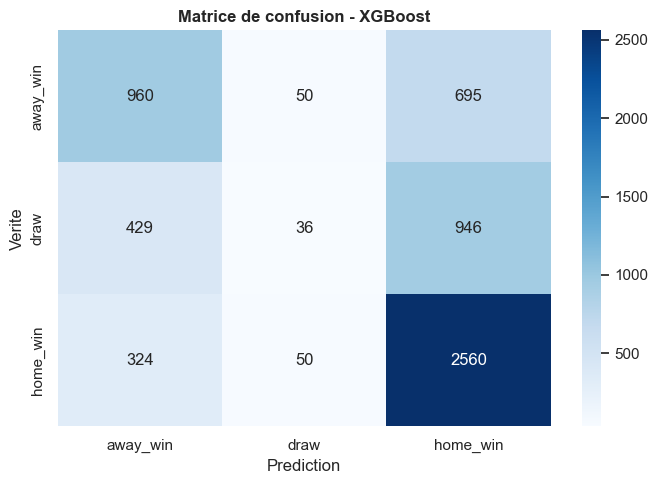


=== Rapport de classification (meilleur modele) ===
              precision    recall  f1-score   support

    away_win       0.56      0.56      0.56      1705
        draw       0.26      0.03      0.05      1411
    home_win       0.61      0.87      0.72      2934

    accuracy                           0.59      6050
   macro avg       0.48      0.49      0.44      6050
weighted avg       0.52      0.59      0.52      6050



In [10]:
recap = pd.DataFrame({
    'Modele': ['Baseline naive', 'Random Forest', 'XGBoost'],
    'Accuracy train': [acc_naive, acc_train_rf, acc_train_xgb],
    'Accuracy test': [acc_naive, acc_test_rf, acc_test_xgb],
}).round(3)
print(recap.to_string(index=False))

modeles = {'Random Forest': model_bagging, 'XGBoost': model_boosting}
accs = {'Random Forest': acc_test_rf, 'XGBoost': acc_test_xgb}
meilleur_nom = max(accs, key=accs.get)
meilleur = modeles[meilleur_nom]
print(f'\n=> Meilleur modele : {meilleur_nom} (accuracy test = {accs[meilleur_nom]:.3f})')

y_pred = meilleur.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_xlabel('Prediction')
ax.set_ylabel('Verite')
ax.set_title(f'Matrice de confusion - {meilleur_nom}', fontweight='bold')
fig.tight_layout()
plt.show()

print('\n=== Rapport de classification (meilleur modele) ===')
print(classification_report(y_test, y_pred, target_names=le.classes_))

### 8. Importance des variables

Le Random Forest expose nativement l'**importance de chaque variable** (importance de Gini). On vérifie ainsi quelles caractéristiques pèsent réellement dans la décision : les variables d'historique enrichi (buts, points pondérés) apportent-elles plus que le simple classement ?

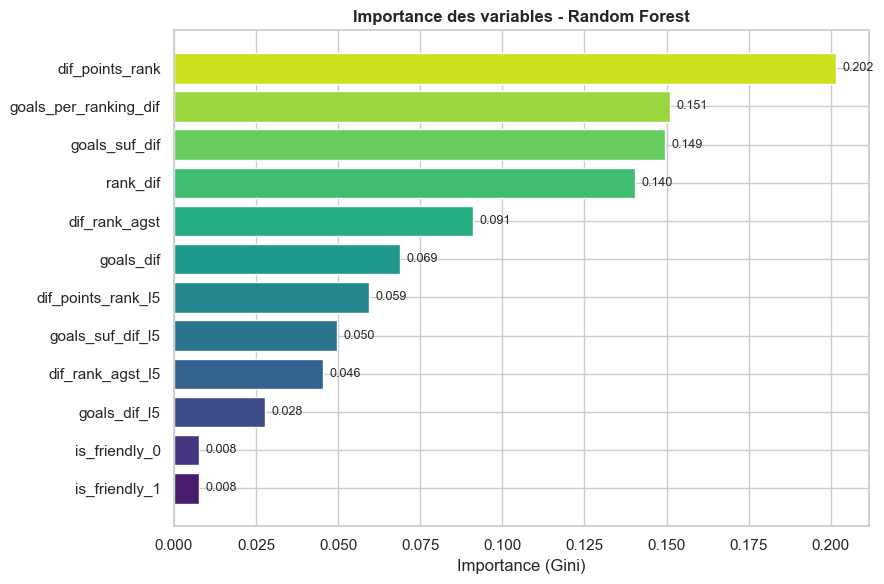


=== Top 5 des variables les plus importantes ===
dif_points_rank          0.202
goals_per_ranking_dif    0.151
goals_suf_dif            0.149
rank_dif                 0.140
dif_rank_agst            0.091


In [11]:
importances = pd.Series(model_bagging.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importances.index, importances.values,
        color=sns.color_palette('viridis', len(importances)))
for i, v in enumerate(importances.values):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)
ax.set_xlabel('Importance (Gini)')
ax.set_title('Importance des variables - Random Forest', fontweight='bold')
fig.tight_layout()
plt.show()

print('\n=== Top 5 des variables les plus importantes ===')
print(importances.sort_values(ascending=False).head(5).round(3).to_string())

### 9. Prédiction des 72 matchs de la phase de groupes (CDM 2026)

On applique le meilleur modèle aux **72 matchs programmés de la phase de groupes** (`data/processed/matches_a_predire.csv`) — soit les 48 équipes réparties en 12 groupes de 4.

Pour chaque équipe, on calcule sa **forme actuelle** : les mêmes moyennes (buts, points pondérés, force du calendrier) mais cette fois sur **l'intégralité** de son historique connu, jusqu'à mars 2026. On reconstruit les 12 variables différentielles, puis on prédit l'issue de chaque match ainsi que les **probabilités** des trois résultats possibles.

In [12]:
# Forme "actuelle" de chaque equipe : moyennes sur tout l'historique + 5 derniers matchs.
def current_form(long_df):
    rows = {}
    for team, sub in long_df.groupby('team', sort=False):
        rows[team] = {
            'goals_mean': sub['goals'].mean(),
            'goals_mean_l5': sub['goals'].tail(5).mean(),
            'goals_suf_mean': sub['goals_suf'].mean(),
            'goals_suf_mean_l5': sub['goals_suf'].tail(5).mean(),
            'rank_mean': sub['opp_rank'].mean(),
            'rank_mean_l5': sub['opp_rank'].tail(5).mean(),
            'game_points_rank_mean': sub['game_points_rank'].mean(),
            'game_points_rank_mean_l5': sub['game_points_rank'].tail(5).mean(),
        }
    return pd.DataFrame(rows).T

form = current_form(long)

df_cdm = pd.read_csv('../data/processed/matches_a_predire.csv')

# On projette la forme de chaque equipe sur ses matchs (cote domicile et exterieur).
for side, team_col in [('home', 'home_team'), ('away', 'away_team')]:
    f = form.loc[df_cdm[team_col]].reset_index(drop=True).add_prefix(side + '_')
    df_cdm = pd.concat([df_cdm, f], axis=1)

# Memes variables differentielles que create_db.
df_cdm['rank_dif'] = df_cdm['home_rank'] - df_cdm['away_rank']
df_cdm['goals_dif'] = df_cdm['home_goals_mean'] - df_cdm['away_goals_mean']
df_cdm['goals_dif_l5'] = df_cdm['home_goals_mean_l5'] - df_cdm['away_goals_mean_l5']
df_cdm['goals_suf_dif'] = df_cdm['home_goals_suf_mean'] - df_cdm['away_goals_suf_mean']
df_cdm['goals_suf_dif_l5'] = df_cdm['home_goals_suf_mean_l5'] - df_cdm['away_goals_suf_mean_l5']
df_cdm['goals_per_ranking_dif'] = (df_cdm['home_goals_mean'] / df_cdm['home_rank_mean']) - \
                                  (df_cdm['away_goals_mean'] / df_cdm['away_rank_mean'])
df_cdm['dif_rank_agst'] = df_cdm['home_rank_mean'] - df_cdm['away_rank_mean']
df_cdm['dif_rank_agst_l5'] = df_cdm['home_rank_mean_l5'] - df_cdm['away_rank_mean_l5']
df_cdm['dif_points_rank'] = df_cdm['home_game_points_rank_mean'] - df_cdm['away_game_points_rank_mean']
df_cdm['dif_points_rank_l5'] = df_cdm['home_game_points_rank_mean_l5'] - df_cdm['away_game_points_rank_mean_l5']
# Les matchs de CDM ne sont jamais amicaux.
df_cdm['is_friendly_0'] = 1
df_cdm['is_friendly_1'] = 0

X_cdm = df_cdm[FEATURES]
preds = meilleur.predict(X_cdm)
probas = meilleur.predict_proba(X_cdm)

df_cdm['prediction'] = le.inverse_transform(preds)
df_cdm['p_home'] = probas[:, list(le.classes_).index('home_win')]
df_cdm['p_draw'] = probas[:, list(le.classes_).index('draw')]
df_cdm['p_away'] = probas[:, list(le.classes_).index('away_win')]
df_cdm['proba_max'] = probas.max(axis=1)

print(f'72 matchs de phase de groupes predits avec {meilleur_nom}.')
print()
print('Repartition des resultats predits :')
print(df_cdm['prediction'].value_counts().to_string())

print('\n=== Top 5 matchs les plus nets ===')
print(df_cdm.nlargest(5, 'proba_max')[
    ['date', 'home_team', 'away_team', 'prediction', 'proba_max']].round(3).to_string(index=False))

72 matchs de phase de groupes predits avec XGBoost.

Repartition des resultats predits :
prediction
home_win    52
away_win    19
draw         1

=== Top 5 matchs les plus nets ===
      date home_team    away_team prediction  proba_max
2026-06-14   Germany      Curaçao   home_win      0.933
2026-06-19    Brazil        Haiti   home_win      0.900
2026-06-15     Spain   Cape Verde   home_win      0.900
2026-06-21     Spain Saudi Arabia   home_win      0.886
2026-06-20   Ecuador      Curaçao   home_win      0.884


### 10. Classement des 12 groupes — qui sort de sa poule ?

On reconstitue maintenant le **classement de chaque groupe** à partir des prédictions. La répartition officielle des 48 équipes (tirage du 5 décembre 2025) est fournie par le module `src/wc2026.py`.

**Comment on classe les équipes ?** Comme dans un vrai classement de football : **par points** (3 victoire / 1 nul / 0 défaite), à partir des 6 matchs internes au groupe.

Problème : le modèle prédit très rarement le match nul, donc beaucoup d'équipes terminent **à égalité de points**. On les départage avec les **points espérés** (`xPts`) :

$$xPts = \sum_{\text{3 matchs}} \big( 3 \times P(\text{victoire}) + 1 \times P(\text{nul}) \big)$$

C'est l'**espérance mathématique** du nombre de points, compte tenu des probabilités du modèle. `xPts` joue ici le rôle que tient la différence de buts dans un vrai classement — un critère fin que notre modèle (qui prédit une *issue*, pas un *score*) ne peut pas fournir directement.

**Format CDM 2026 :** les **2 premiers** de chaque groupe + les **8 meilleurs 3ᵉˢ** se qualifient → 32 équipes pour les 16ᵉˢ de finale. C'est cette liste qui servira de point de départ au notebook 06.

In [13]:
# Points esperes : esperance mathematique des points selon les probabilites du modele.
df_cdm['xpts_home'] = 3 * df_cdm['p_home'] + df_cdm['p_draw']
df_cdm['xpts_away'] = 3 * df_cdm['p_away'] + df_cdm['p_draw']

# Classement de chaque groupe a partir des 6 matchs internes.
lignes = []
for grp, equipes in wc2026.GROUPS.items():
    for t in equipes:
        dom = df_cdm[df_cdm['home_team'] == t]
        ext = df_cdm[df_cdm['away_team'] == t]
        v = int((dom['prediction'] == 'home_win').sum() + (ext['prediction'] == 'away_win').sum())
        n = int((dom['prediction'] == 'draw').sum() + (ext['prediction'] == 'draw').sum())
        d = int((dom['prediction'] == 'away_win').sum() + (ext['prediction'] == 'home_win').sum())
        xpts = dom['xpts_home'].sum() + ext['xpts_away'].sum()
        lignes.append({'groupe': grp, 'equipe': t, 'V': v, 'N': n, 'D': d,
                       'points': 3 * v + n, 'xPts': round(float(xpts), 2)})

# Classement : par points, puis xPts en cas d'egalite (comme la difference de buts).
classement = pd.DataFrame(lignes).sort_values(
    ['groupe', 'points', 'xPts'], ascending=[True, False, False]).reset_index(drop=True)
classement['rang'] = classement.groupby('groupe').cumcount() + 1

# Affichage des 12 classements de groupe.
for grp in wc2026.GROUPS:
    bloc = classement[classement['groupe'] == grp]
    print(f'--- Groupe {grp} ---')
    print(bloc[['rang', 'equipe', 'V', 'N', 'D', 'points', 'xPts']].to_string(index=False))
    print()

--- Groupe A ---
 rang         equipe  V  N  D  points  xPts
    1         Mexico  3  0  0       9  6.02
    2    South Korea  2  0  1       6  3.57
    3 Czech Republic  1  0  2       3  4.55
    4   South Africa  0  0  3       0  2.26

--- Groupe B ---
 rang                 equipe  V  N  D  points  xPts
    1            Switzerland  3  0  0       9  5.64
    2                 Canada  2  0  1       6  4.87
    3 Bosnia and Herzegovina  1  0  2       3  3.47
    4                  Qatar  0  0  3       0  2.45

--- Groupe C ---
 rang   equipe  V  N  D  points  xPts
    1   Brazil  3  0  0       9  7.34
    2 Scotland  2  0  1       6  4.11
    3  Morocco  1  0  2       3  4.24
    4    Haiti  0  0  3       0  1.10

--- Groupe D ---
 rang        equipe  V  N  D  points  xPts
    1 United States  3  0  0       9  5.98
    2     Australia  1  0  2       3  3.62
    3        Turkey  1  0  2       3  3.59
    4      Paraguay  1  0  2       3  3.16

--- Groupe E ---
 rang      equipe  V  N  D

#### Vainqueurs de groupe et équipes qualifiées

In [14]:
# Les 12 vainqueurs de groupe.
vainqueurs = classement[classement['rang'] == 1].sort_values(
    ['points', 'xPts'], ascending=False)
print('=== Vainqueurs predits des 12 groupes ===')
print(vainqueurs[['groupe', 'equipe', 'V', 'N', 'D', 'points', 'xPts']].to_string(index=False))

# Equipe la plus performante en phase de groupes.
top = classement.sort_values(['points', 'xPts'], ascending=False).iloc[0]
print(f"\n>>> Equipe la plus performante en phase de groupes : {top['equipe']} "
      f"(groupe {top['groupe']}, {top['V']} victoires, {top['points']} points, "
      f"{top['xPts']:.2f} points esperes).")

# Qualifies : 2 premiers de chaque groupe + 8 meilleurs 3es = 32 equipes.
directs = classement[classement['rang'] <= 2]
troisiemes = classement[classement['rang'] == 3].sort_values(
    ['points', 'xPts'], ascending=False).head(8)
qualifies = pd.concat([directs, troisiemes]).sort_values(
    ['points', 'xPts'], ascending=False).reset_index(drop=True)

print(f'\n=== {len(qualifies)} equipes qualifiees pour les 16es de finale ===')
print('Les 8 meilleurs 3es repeches :')
print(troisiemes[['groupe', 'equipe', 'points', 'xPts']].to_string(index=False))

# Sauvegarde pour le notebook 06 (phase a elimination directe).
qualifies[['groupe', 'rang', 'equipe', 'V', 'N', 'D', 'points', 'xPts']].to_csv(
    '../data/processed/cdm2026_qualifies.csv', index=False)
print('\nListe des qualifies sauvegardee -> data/processed/cdm2026_qualifies.csv')

=== Vainqueurs predits des 12 groupes ===
groupe        equipe  V  N  D  points  xPts
     C        Brazil  3  0  0       9  7.34
     F         Spain  3  0  0       9  7.15
     J     Argentina  3  0  0       9  7.04
     L       England  3  0  0       9  6.97
     I        France  3  0  0       9  6.89
     H   Netherlands  3  0  0       9  6.54
     G       Belgium  3  0  0       9  6.45
     A        Mexico  3  0  0       9  6.02
     D United States  3  0  0       9  5.98
     K      Colombia  3  0  0       9  5.90
     B   Switzerland  3  0  0       9  5.64
     E       Germany  2  1  0       7  6.59

>>> Equipe la plus performante en phase de groupes : Brazil (groupe C, 3 victoires, 9 points, 7.34 points esperes).



=== 32 equipes qualifiees pour les 16es de finale ===
Les 8 meilleurs 3es repeches :
groupe                 equipe  points  xPts
     E                Ecuador       4  5.17
     A         Czech Republic       3  4.55
     C                Morocco       3  4.24
     J                Austria       3  4.16
     G                   Iran       3  4.11
     D                 Turkey       3  3.59
     B Bosnia and Herzegovina       3  3.47
     H                 Sweden       3  3.47

Liste des qualifies sauvegardee -> data/processed/cdm2026_qualifies.csv


### 11. Synthèse — modélisation

1. **Les deux modèles battent largement la baseline naïve** (~48.5 %) : le *feature engineering* enrichi (historique de buts, forme récente, force du calendrier) apporte un vrai signal prédictif.
2. **Le passage du classement FIFA seul aux 12 variables différentielles fait progresser la précision de test** — voir le tableau récapitulatif du §7. Les variables d'historique (`dif_points_rank`, `goals_per_ranking_dif`, `goals_suf_dif`) figurent en tête de l'importance, aux côtés du `rank_dif`.
3. **Random Forest et XGBoost** restent au coude-à-coude, conformément à la littérature sur les données tabulaires (§5.1 du cours : *les arbres dominent encore le tabulaire face au Deep Learning*).
4. **Phase de groupes CDM 2026** : les 72 matchs sont prédits, puis agrégés en **classement des 12 groupes** via les points espérés (`xPts`). On en déduit les 12 vainqueurs de groupe et les **32 équipes qualifiées** pour les 16ᵉˢ de finale.
5. **Limites identifiées** : la classe `draw` reste sous-prédite (matchs nuls intrinsèquement difficiles) ; chaque match est prédit indépendamment.

➡️ Le notebook suivant (`06_evaluation`) approfondira l'évaluation (validation croisée temporelle, métriques par classe) puis exploitera la liste des 32 qualifiés pour **simuler la phase à élimination directe** et désigner le vainqueur de la Coupe du Monde.